In [1]:
# conduncting an EDA to get a better understanding of the data
# 1. Data overview
# 2. Target analysis (isFraud)
# 3. Missing values
# 4. Numeric feature behavior
# 5. Categorical feature behavior
# 6. Time-based patterns



import sys
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Initialize DuckDB connection for efficient large-scale analysis
con = duckdb.connect()

# DuckDB connection
TRANSACTION_PATH = "../data/raw/train_transaction.csv"
IDENTITY_PATH = "../data/raw/train_identity.csv"

In [2]:
# Joining on transaction ID
# verified that we have the correct amount of rows merged
con.execute(f"""
SELECT COUNT(*) AS total_rows
FROM '{TRANSACTION_PATH}' t
LEFT JOIN '{IDENTITY_PATH}' i
ON t.TransactionID = i.TransactionID
""").df()

,total_rows
0,590540


In [3]:
# previewing the table to get a sense of the data
con.execute(f"""
SELECT *
FROM '{TRANSACTION_PATH}' t
LEFT JOIN '{IDENTITY_PATH}' i
ON t.TransactionID = i.TransactionID
LIMIT 5
""").df()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3002016,0,418018,25.000,H,5014,399.0,150.0,american express,146.0,...,chrome 62.0,24.0,1366x768,match_status:2,True,False,True,True,desktop,Windows
1,3002017,0,418079,200.000,H,5938,111.0,150.0,visa,162.0,...,edge 14.0,24.0,1600x900,match_status:2,True,True,True,True,desktop,Windows
2,3002018,0,418089,50.000,H,2249,343.0,150.0,visa,195.0,...,chrome 62.0,24.0,1440x900,match_status:2,True,False,True,True,desktop,Windows
3,3002021,0,418148,85.555,C,4815,555.0,119.0,visa,226.0,...,chrome 62.0,NaN,None,None,False,False,True,True,desktop,Windows
4,3002029,0,418235,8.398,C,5812,408.0,185.0,mastercard,224.0,...,firefox 57.0,NaN,None,None,False,False,True,True,desktop,None


In [4]:
# Target Analysis
# There seems to be an imbalance with the isFraud feature
# Roughly 3-4% (20,633 transactions) of the values are confirmed to be fraud
# 96-97% (569,877 transactions) are non fraud transactions

# Count fraud vs non-fraud
target_counts = con.execute(f"""
SELECT 
    isFraud,
    COUNT(*) AS Count
FROM '{TRANSACTION_PATH}'
GROUP BY isFraud
ORDER BY isFraud
""").df()

target_counts["Percentage"] = (
    target_counts["Count"] / target_counts["Count"].sum()
) * 100

target_counts

,isFraud,Count,Percentage
0,0,569877,96.500999
1,1,20663,3.499001


In [5]:
# Get columns separately so DuckDB knows which table each feature comes from
trans_cols = con.execute(f"""
SELECT *
FROM '{TRANSACTION_PATH}'
LIMIT 1
""").df().columns.tolist()

id_cols = con.execute(f"""
SELECT *
FROM '{IDENTITY_PATH}'
LIMIT 1
""").df().columns.tolist()

missing_exprs = []

# Transaction table columns
for col in trans_cols:
    missing_exprs.append(
        f'SUM(CASE WHEN t."{col}" IS NULL THEN 1 ELSE 0 END) AS "{col}"'
    )

# Identity table columns, skipping duplicate TransactionID
for col in id_cols:
    if col != "TransactionID":
        missing_exprs.append(
            f'SUM(CASE WHEN i."{col}" IS NULL THEN 1 ELSE 0 END) AS "{col}"'
        )

query = f"""
SELECT
    COUNT(*) AS total_rows,
    {", ".join(missing_exprs)}
FROM '{TRANSACTION_PATH}' t
LEFT JOIN '{IDENTITY_PATH}' i
ON t.TransactionID = i.TransactionID
"""

missing_counts = con.execute(query).df()

total_rows = missing_counts["total_rows"][0]

missing_table = (
    missing_counts
    .drop(columns=["total_rows"])
    .T
    .reset_index()
)

missing_table.columns = ["Feature", "Missing_Count"]

missing_table["Missing_Percentage"] = (
    missing_table["Missing_Count"] / total_rows
)

missing_table = missing_table.sort_values(
    "Missing_Percentage",
    ascending=False
)

missing_table.head(30)

,Feature,Missing_Count,Missing_Percentage
417,id_24,585793.0,0.991962
418,id_25,585408.0,0.991310
400,id_07,585385.0,0.991271
401,id_08,585385.0,0.991271
414,id_21,585381.0,0.991264
419,id_26,585377.0,0.991257
420,id_27,585371.0,0.991247
416,id_23,585371.0,0.991247
415,id_22,585371.0,0.991247
14,dist2,552913.0,0.936284


In [6]:
missing_table["Missing_Type"] = pd.cut(
    missing_table["Missing_Percentage"],
    bins=[0, 0.2, 0.5, 0.9, 1],
    labels=[
        "Low (<20%)",
        "Moderate (20–50%)",
        "High (50–90%)",
        "Extreme (>90%)"
    ]
)

missing_table.head(10)
missing_table.tail(20)
missing_table["Missing_Percentage"].describe()

count    434.000000
mean       0.450744
std        0.365432
min        0.000000
25%        0.002663
50%        0.472935
75%        0.779134
max        0.991962
Name: Missing_Percentage, dtype: float64

In [7]:
# Get transaction columns
trans_cols = con.execute(f"""
SELECT *
FROM '{TRANSACTION_PATH}'
LIMIT 1
""").df().columns.tolist()

# Get identity columns
id_cols = con.execute(f"""
SELECT *
FROM '{IDENTITY_PATH}'
LIMIT 1
""").df().columns.tolist()

# Combine them (avoid duplicate TransactionID)
columns = trans_cols + [col for col in id_cols if col != "TransactionID"]

len(columns)

434

In [8]:
# here, I am checking for two things:
# How often is this column value missing in fraud?
# How often is it missing in non-fraud?
# This is being done to see if I can treat missingness as a predictive feature
# missing values may reflect differences in data collection or behavior patterns, which can correlate with fraudulent activity

# math example
# | P(missing feature | fraud) − P(missing feature| non-fraud) |
# say we have 6 rows where we have 3 fraud and 3 non-fraud values
# for the fraud, we find that device info is missing for 2 out of 3 transactions
# so, we take P(2|3) = .67
# and we find that in the non-fraud, we got 1 missing device information out of three
# now, we have P(1|3) = .33
# | P(missing feature | fraud) − P(missing feature| non-fraud) | = .34
# this is a strong signal, it means that missing DeviceInfo is MUCH more common in fraud
signal_exprs = []

for col in columns:
    if col == "TransactionID":
        continue

    table_alias = "t" if col in trans_cols else "i"

    signal_exprs.append(f"""
        ABS(
            (
                SUM(CASE WHEN isFraud = 1 AND {table_alias}."{col}" IS NULL THEN 1 ELSE 0 END)
                /
                NULLIF(SUM(CASE WHEN isFraud = 1 THEN 1 ELSE 0 END), 0)
            )
            -
            (
                SUM(CASE WHEN isFraud = 0 AND {table_alias}."{col}" IS NULL THEN 1 ELSE 0 END)
                /
                NULLIF(SUM(CASE WHEN isFraud = 0 THEN 1 ELSE 0 END), 0)
            )
        ) AS "{col}"
    """)

query = f"""
SELECT
    {", ".join(signal_exprs)}
FROM '{TRANSACTION_PATH}' t
LEFT JOIN '{IDENTITY_PATH}' i
ON t.TransactionID = i.TransactionID
"""

signal_counts = con.execute(query).df()

signal_table = signal_counts.T.reset_index()
signal_table.columns = ["Feature", "Missing_Signal"]

signal_table.sort_values("Missing_Signal", ascending=False).head(20)

,Feature,Missing_Signal
15,R_emaildomain,0.322126
394,id_02,0.315591
430,id_38,0.315393
429,id_37,0.315393
428,id_36,0.315393
427,id_35,0.315393
407,id_15,0.315393
420,id_28,0.315205
421,id_29,0.315205
403,id_11,0.315205


In [9]:
feature_analysis = missing_table.merge(
    signal_table,
    on="Feature",
    how="left"
)

feature_analysis.head(30)

,Feature,Missing_Count,Missing_Percentage,Missing_Type,Missing_Signal
0,id_24,585793.0,0.991962,Extreme (>90%),0.011831
1,id_25,585408.0,0.991310,Extreme (>90%),0.011907
2,id_07,585385.0,0.991271,Extreme (>90%),0.012318
3,id_08,585385.0,0.991271,Extreme (>90%),0.012318
4,id_21,585381.0,0.991264,Extreme (>90%),0.012311
5,id_26,585377.0,0.991257,Extreme (>90%),0.012254
6,id_27,585371.0,0.991247,Extreme (>90%),0.012294
7,id_23,585371.0,0.991247,Extreme (>90%),0.012294
8,id_22,585371.0,0.991247,Extreme (>90%),0.012294
9,dist2,552913.0,0.936284,Extreme (>90%),0.121085


In [10]:
# | Value | Meaning                 |
# | ----- | ----------------------- |
# | 0.00  | no difference → useless |
# | 0.01  | very weak               |
# | 0.05  | moderate                |
# | 0.10  | strong                  |
# | 0.30+ | extremely strong        |


low_signal_threshold = feature_analysis["Missing_Signal"].quantile(0.10)

def feature_decision(row):
    if row["Feature"] == "TransactionID":
        return "Drop: Identifier"
    
    # THIS is the key rule
    if row["Missing_Percentage"] >= 0.98 and row["Missing_Signal"] < 0.02:
        return "Drop: Extreme Missing + Weak Signal"
    
    if row["Missing_Signal"] >= 0.20:
        return "Keep: Strong"
    
    if row["Missing_Signal"] >= 0.05:
        return "Keep: Moderate"
    
    if row["Missing_Percentage"] >= 0.60:
        return "Investigate"
    
    return "Keep"
feature_analysis["Decision"] = feature_analysis.apply(feature_decision, axis=1)
feature_analysis.head()

,Feature,Missing_Count,Missing_Percentage,Missing_Type,Missing_Signal,Decision
0,id_24,585793.0,0.991962,Extreme (>90%),0.011831,Drop: Extreme Missing + Weak Signal
1,id_25,585408.0,0.991310,Extreme (>90%),0.011907,Drop: Extreme Missing + Weak Signal
2,id_07,585385.0,0.991271,Extreme (>90%),0.012318,Drop: Extreme Missing + Weak Signal
3,id_08,585385.0,0.991271,Extreme (>90%),0.012318,Drop: Extreme Missing + Weak Signal
4,id_21,585381.0,0.991264,Extreme (>90%),0.012311,Drop: Extreme Missing + Weak Signal


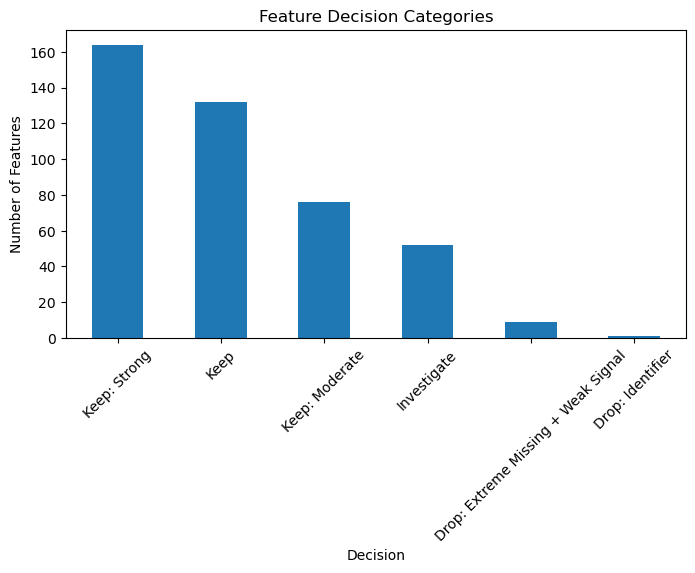

In [11]:
feature_analysis["Decision"].value_counts().plot(kind="bar", figsize=(8, 4))

plt.title("Feature Decision Categories")
plt.xlabel("Decision")
plt.ylabel("Number of Features")
plt.xticks(rotation=45)
plt.show()

In [12]:
feature_analysis.sort_values("Missing_Signal", ascending=False).head(20)

,Feature,Missing_Count,Missing_Percentage,Missing_Type,Missing_Signal,Decision
125,R_emaildomain,453249.0,0.767516,High (50–90%),0.322126,Keep: Strong
181,id_02,449668.0,0.761452,High (50–90%),0.315591,Keep: Strong
189,id_38,449555.0,0.761261,High (50–90%),0.315393,Keep: Strong
188,id_35,449555.0,0.761261,High (50–90%),0.315393,Keep: Strong
187,id_15,449555.0,0.761261,High (50–90%),0.315393,Keep: Strong
186,id_36,449555.0,0.761261,High (50–90%),0.315393,Keep: Strong
185,id_37,449555.0,0.761261,High (50–90%),0.315393,Keep: Strong
184,id_28,449562.0,0.761273,High (50–90%),0.315205,Keep: Strong
183,id_11,449562.0,0.761273,High (50–90%),0.315205,Keep: Strong
182,id_29,449562.0,0.761273,High (50–90%),0.315205,Keep: Strong


In [13]:
feature_analysis[
    feature_analysis["Decision"].str.contains("Drop")
]

,Feature,Missing_Count,Missing_Percentage,Missing_Type,Missing_Signal,Decision
0,id_24,585793.0,0.991962,Extreme (>90%),0.011831,Drop: Extreme Missing + Weak Signal
1,id_25,585408.0,0.991310,Extreme (>90%),0.011907,Drop: Extreme Missing + Weak Signal
2,id_07,585385.0,0.991271,Extreme (>90%),0.012318,Drop: Extreme Missing + Weak Signal
3,id_08,585385.0,0.991271,Extreme (>90%),0.012318,Drop: Extreme Missing + Weak Signal
4,id_21,585381.0,0.991264,Extreme (>90%),0.012311,Drop: Extreme Missing + Weak Signal
5,id_26,585377.0,0.991257,Extreme (>90%),0.012254,Drop: Extreme Missing + Weak Signal
6,id_27,585371.0,0.991247,Extreme (>90%),0.012294,Drop: Extreme Missing + Weak Signal
7,id_23,585371.0,0.991247,Extreme (>90%),0.012294,Drop: Extreme Missing + Weak Signal
8,id_22,585371.0,0.991247,Extreme (>90%),0.012294,Drop: Extreme Missing + Weak Signal
433,TransactionID,0.0,0.000000,NaN,NaN,Drop: Identifier


In [14]:
keep_features = feature_analysis[
    feature_analysis["Decision"].str.contains("Keep")
]["Feature"].tolist()

In [15]:
feature_analysis["Missing_Signal"].describe()

count    433.000000
mean       0.129093
std        0.129736
min        0.000000
25%        0.000801
50%        0.061445
75%        0.282259
max        0.322126
Name: Missing_Signal, dtype: float64

In [16]:
feature_analysis[
    feature_analysis["Missing_Percentage"] >= 0.95
].sort_values("Missing_Signal").head(20)

,Feature,Missing_Count,Missing_Percentage,Missing_Type,Missing_Signal,Decision
0,id_24,585793.0,0.991962,Extreme (>90%),0.011831,Drop: Extreme Missing + Weak Signal
1,id_25,585408.0,0.991310,Extreme (>90%),0.011907,Drop: Extreme Missing + Weak Signal
5,id_26,585377.0,0.991257,Extreme (>90%),0.012254,Drop: Extreme Missing + Weak Signal
6,id_27,585371.0,0.991247,Extreme (>90%),0.012294,Drop: Extreme Missing + Weak Signal
7,id_23,585371.0,0.991247,Extreme (>90%),0.012294,Drop: Extreme Missing + Weak Signal
8,id_22,585371.0,0.991247,Extreme (>90%),0.012294,Drop: Extreme Missing + Weak Signal
4,id_21,585381.0,0.991264,Extreme (>90%),0.012311,Drop: Extreme Missing + Weak Signal
2,id_07,585385.0,0.991271,Extreme (>90%),0.012318,Drop: Extreme Missing + Weak Signal
3,id_08,585385.0,0.991271,Extreme (>90%),0.012318,Drop: Extreme Missing + Weak Signal


In [17]:
drop_features = feature_analysis[
    (feature_analysis["Feature"] == "TransactionID") |
    (
        (feature_analysis["Missing_Percentage"] >= 0.98) &
        (feature_analysis["Missing_Signal"] < 0.02)
    )
]["Feature"].tolist()



In [18]:
# 1. TransactionAmt vs fraud - Are higher or unusually low transaction amounts more associated with fraud?
# 2. ProductCD fraud rate - Are certain product types disproportionately targeted for fraud?
# 3. Email domain fraud rate - Do certain email domains have higher fraud rates than others?
# 4. Time patterns - Are fraud transactions more frequent during certain hours of the day?
# 5. Numeric correlation (sample) - Which features have the highest correlation with the target variable (isFraud)?

In [19]:
# 1. TransactionAmt vs fraud - Are higher or unusually low transaction amounts more associated with fraud?
# Fraud tends to involve slightly larger amounts, BUT not a huge difference
# Fraud transactions extend higher in typical range
# Fraud includes MORE low-value transactions
# Interpretation (behavioral)
# Why low amounts?
# Fraudsters test cards with small transactions
# Why high amounts?
# Once validated → they attempt larger fraud
# Fraud transactions showed a slightly higher median and a wider upper range, while also including more low-value transactions. This suggests fraud occurs at both low and high transaction amounts, likely reflecting card testing behavior followed by larger fraudulent activity.

df_amt = con.execute(f"""
SELECT isFraud, TransactionAmt
FROM '{TRANSACTION_PATH}'
""").df()
df_amt.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


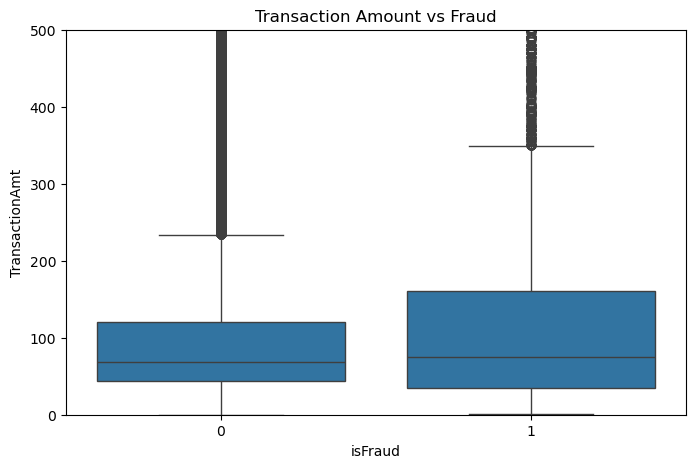

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="isFraud", y="TransactionAmt", data=df_amt)
plt.title("Transaction Amount vs Fraud")
plt.ylim(0, 500)  # zoom in to remove extreme outliers
plt.show()

# from the box plot we can see that:
# Fraud transactions are more variable
# Higher-value transactions are more common in fraud
# More small transactions in fraud
# Fraud is NOT just “high amount”
# Fraud is “abnormal amount behavior”
# more low-value transactions (testing)
# more high-value transactions (actual fraud)
# wider variability overall



# from here, i discovered that TransactionAmt relationship is NON-LINEAR so simple linear models won't capture this well
# Tree models will be able to better capture the data
# TransactionAmt alone is NOT a strong classifier

In [21]:
# 2. ProductCD fraud rate - Are certain product types disproportionately targeted for fraud?
df_prod = con.execute(f"""
SELECT isFraud, ProductCD
FROM '{TRANSACTION_PATH}'
""").df()

fraud_rate = df_prod.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False)

fraud_rate

# ProductCD has strong predictive power  
# Clear separation between categories  
# Much stronger than TransactionAmt  
# Should definitely be kept
# IF ProductCD = C → higher fraud probability  (6x more likely to be fraud)
# IF ProductCD = W → lower fraud probability

ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64

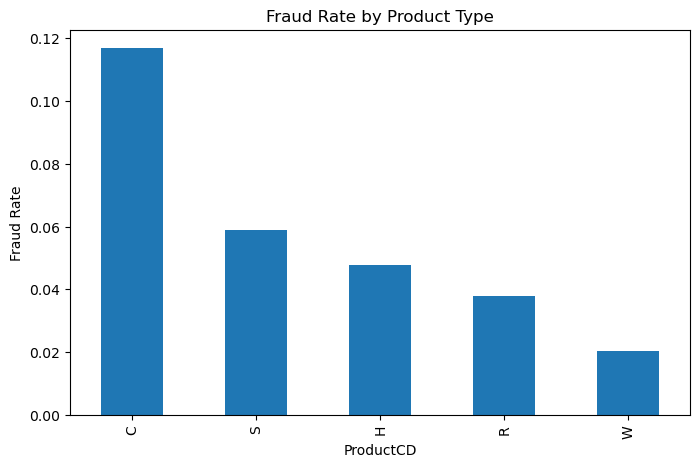

In [22]:
fraud_rate.plot(kind="bar", figsize=(8,5))
plt.title("Fraud Rate by Product Type")
plt.ylabel("Fraud Rate")
plt.xlabel("ProductCD")
plt.show()

In [23]:
# 3. Email domain fraud rate - Do certain email domains have higher fraud rates than others?
# 3. Email domain fraud rate
# Question: Do certain payer or receiver email domains have higher fraud rates?

# Pull payer and receiver email domains
df_email = con.execute(f"""
SELECT 
    isFraud,
    P_emaildomain,
    R_emaildomain
FROM '{TRANSACTION_PATH}'
""").df()

In [24]:
# Payer email fraud rate
p_email_fraud = (
    df_email
    .groupby("P_emaildomain")["isFraud"]
    .mean()
    .sort_values(ascending=False)
)

p_email_counts = df_email["P_emaildomain"].value_counts()

p_email_df = pd.DataFrame({
    "fraud_rate": p_email_fraud,
    "count": p_email_counts
}).reset_index()

p_email_df = p_email_df.rename(columns={"index": "P_emaildomain"})

p_email_df.sort_values("fraud_rate", ascending=False).head(20)

,P_emaildomain,fraud_rate,count
38,protonmail.com,0.407895,76
29,mail.com,0.189624,559
36,outlook.es,0.130137,438
0,aim.com,0.126984,315
35,outlook.com,0.094584,5096
21,hotmail.es,0.065574,305
26,live.com.mx,0.054740,749
19,hotmail.com,0.052950,45250
16,gmail.com,0.043542,228355
57,yahoo.fr,0.034965,143


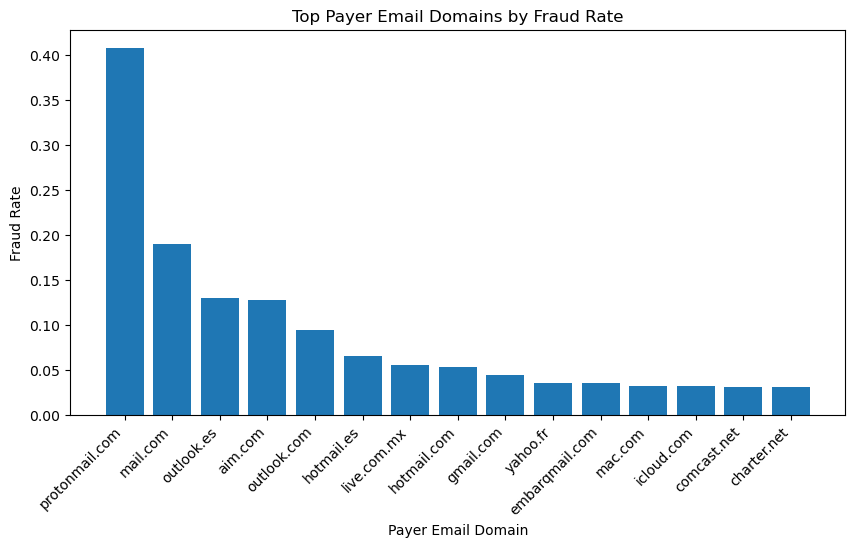

In [25]:
# Visualize top payer domains by fraud rate
top_p_domains = p_email_df.sort_values("fraud_rate", ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_p_domains["P_emaildomain"], top_p_domains["fraud_rate"])

plt.title("Top Payer Email Domains by Fraud Rate")
plt.xlabel("Payer Email Domain")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

In [26]:
# Receiver email fraud rate
r_email_fraud = (
    df_email
    .groupby("R_emaildomain")["isFraud"]
    .mean()
    .sort_values(ascending=False)
)

r_email_counts = df_email["R_emaildomain"].value_counts()

r_email_df = pd.DataFrame({
    "fraud_rate": r_email_fraud,
    "count": r_email_counts
}).reset_index()

r_email_df = r_email_df.rename(columns={"index": "R_emaildomain"})

r_email_df.sort_values("fraud_rate", ascending=False).head(20)

,R_emaildomain,fraud_rate,count
38,protonmail.com,0.951220,41
29,mail.com,0.377049,122
33,netzero.net,0.222222,9
35,outlook.com,0.165138,2507
36,outlook.es,0.131640,433
23,icloud.com,0.128755,1398
16,gmail.com,0.119184,57147
19,hotmail.com,0.077793,27509
11,earthlink.net,0.075949,79
21,hotmail.es,0.068493,292


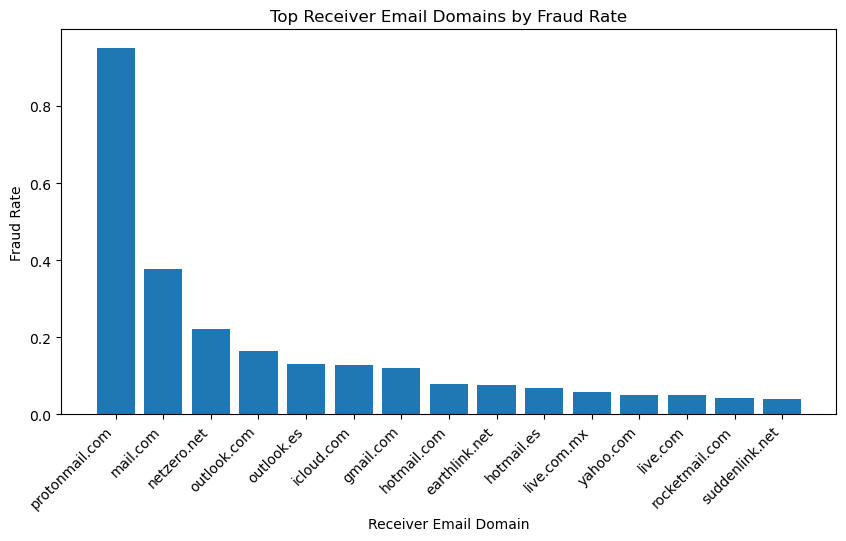

In [27]:
# Visualize top receiver domains by fraud rate
# By looking at the data above, it is obvious that protonmail is associated with the majority of the frauds
top_r_domains = r_email_df.sort_values("fraud_rate", ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_r_domains["R_emaildomain"], top_r_domains["fraud_rate"])

plt.title("Top Receiver Email Domains by Fraud Rate")
plt.xlabel("Receiver Email Domain")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

In [28]:
# Optional: check email domain matching
df_email["email_match"] = (
    df_email["P_emaildomain"] == df_email["R_emaildomain"]
).astype(int)

df_email.groupby("email_match")["isFraud"].mean()
# create a cleaner email match summary
email_match_summary = (
    df_email
    .groupby("email_match")
    .agg(
        transaction_count=("isFraud", "count"),
        fraud_rate=("isFraud", "mean")
    )
    .reset_index()
)

email_match_summary

,email_match,transaction_count,fraud_rate
0,0,488036,0.022070
1,1,102504,0.096504


In [29]:
# I analyzed both payer and receiver email domains and found that receiver domains exhibited stronger fraud signals, indicating that fraud behavior is more closely tied to transaction destinations. I also engineered an interaction feature capturing whether the domains match, which revealed that same-domain transactions were significantly more likely to be fraudulent
# P_emaildomain → moderate signal  
# R_emaildomain → strong signal  
# P vs R interaction → VERY strong signal  
# Fraud behavior is structured, not random
# Same-domain transactions are ~4.4x more likely to be fraud

In [30]:
# 4. Time patterns - Are fraud transactions more frequent during certain hours of the day?
# time to analyze the time patters for this data set
# there might be specific times when criminals make fraudulent transactions

# finding all fraudulent transactions and converting them to an hourly format
df_time = con.execute(f"""
SELECT
    isFraud,
    TransactionDT,
    FLOOR((TransactionDT / 3600) % 24) AS hour
FROM '{TRANSACTION_PATH}'
""").df()

df_time.head()

# grouping fraud rate by hour
fraud_by_hour = (
    df_time
    .groupby("hour")["isFraud"]
    .mean()
)

fraud_by_hour

hour
0.0     0.031380
1.0     0.031314
2.0     0.037483
3.0     0.038314
4.0     0.051890
5.0     0.070302
6.0     0.077743
7.0     0.106102
8.0     0.093014
9.0     0.089956
10.0    0.053212
11.0    0.038816
12.0    0.030439
13.0    0.022889
14.0    0.024216
15.0    0.025399
16.0    0.029511
17.0    0.031530
18.0    0.035231
19.0    0.034738
20.0    0.034273
21.0    0.034005
22.0    0.032694
23.0    0.036997
Name: isFraud, dtype: float64

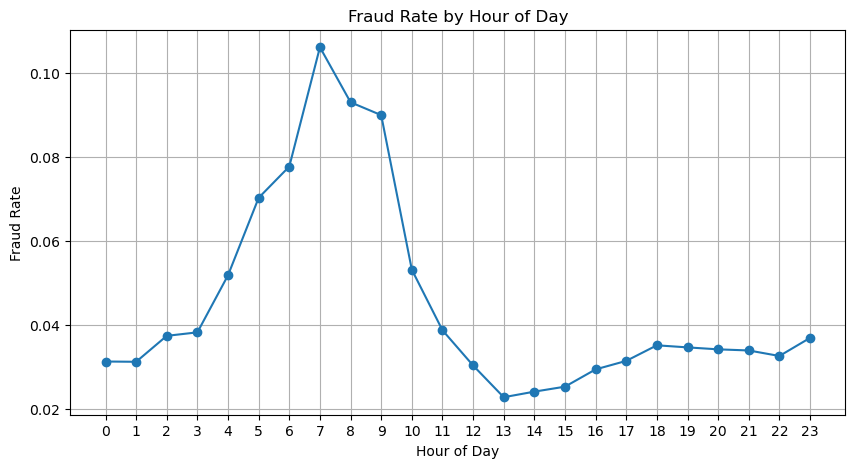

In [33]:
# it appears that the fraud rate increased from 12am-7am, but slowly started to decline after
# I wonder if this is due to the fact that most people

plt.figure(figsize=(10,5))

fraud_by_hour.plot(kind="line", marker="o")

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")

plt.xticks(range(24))
plt.grid(True)

plt.show()

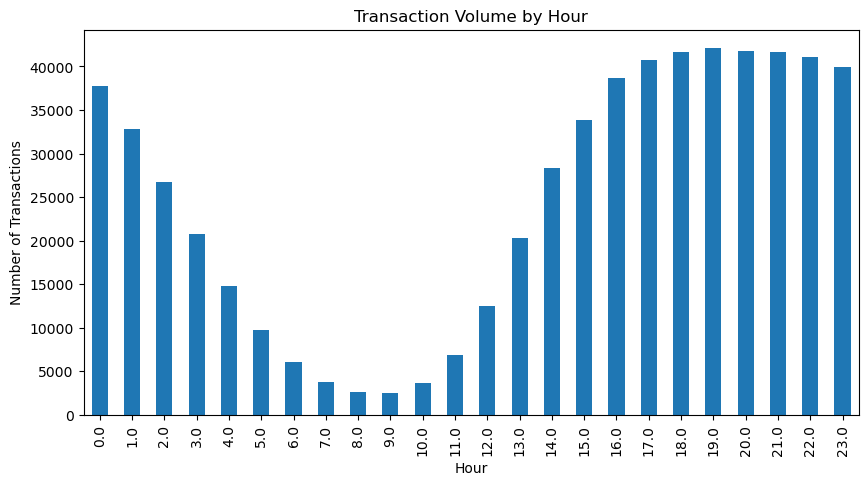

In [32]:
transaction_volume = (
    df_time
    .groupby("hour")
    .size()
)

transaction_volume.plot(kind="bar", figsize=(10,5))

plt.title("Transaction Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.show()